<a href="https://colab.research.google.com/github/jiyanshud22/Saltmine-Auto-Zoning-and-Stacking/blob/main/Cleaned_AR1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
"""
Floor 4 (L004) Zoning Data Processing Script
=============================================
Reads Excel zoning data + JSON spatial data, matches blocks to spatial zones,
and produces a unified zoning output dataset.
"""

import json
import re
import math
import warnings
import pandas as pd
import os

warnings.filterwarnings("ignore")

EXCEL_PATH = "/content/AR1 - Cleaned Zoning Data.xlsx"
JSON_PATH  = "/content/AR1_L004Floor 03 - Spatial data.json"


# ─────────────────────────────────────────────
# 1. LOAD EXCEL SHEETS
# ─────────────────────────────────────────────

def load_level4_blocks(path: str) -> pd.DataFrame:
    """Load Level 4 block data and clean dtypes."""
    df = pd.read_excel(path, sheet_name="Level 4 - Block Data", dtype=str)

    numeric_cols = [
        "Block_ID", "Block_Area", "Block_Capacity", "Required_Number_Units",
        "circulation cut- through rule", "zone splittable by circulation",
        "Cumulative Block Area_(SQM)", "Circulation_(SQM)",
        "Cumulative_Block_Circulation_Area",
        "Code_compliance_factor", "Max_Occupancy_by_Block", "Max_Occupancy_with_Capacity",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Drop footer artifact rows (Block_ID is NaN and Block_Name looks like a long concat)
    df = df[df["Block_ID"].notna()].copy()
    df["Block_ID"] = df["Block_ID"].astype("Int64")

    # Clean string columns
    str_cols = [
        "Block_Name", "Block_Instance_Name", "Manual_Stack_Levels", "Block_Type",
        "Department_Sub_Department", "Department Name_Level1", "Department Name_Level2",
        "Department Name_Level3", "SpaceMix_(ME_WE_US_Support_Speciality)",
        "Typical_Destination", "Open/Closed",
        "travel distance between specific blocks",
        "Groups designations for from-to travel distance",
        "pre-processed placement-bundles_Logic 1",
        "Block_Dim_Design_Block_Catalogue",
    ]
    for col in str_cols:
        if col in df.columns:
            df[col] = df[col].fillna("").str.strip()

    return df.reset_index(drop=True)


def load_block_building_adjacency(path: str) -> pd.DataFrame:
    """Sheet 9: Block to Building Feature adjacency."""
    df = pd.read_excel(path, sheet_name="Block to Building Feature Adjac", dtype=str)
    feat_cols = ["AHU", "Window/Glazing Wall/Periferral Glazing", "Main Entry",
                 "Toilets", "Service Entry", "Fire Egress/Fire exit",
                 "Terrace/ Balcony", "Core"]
    for c in feat_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)
    return df


def load_sf_adjacency(path: str, sheet: str) -> pd.DataFrame:
    """Load SF-to-SF adjacency matrix (min or max), return tidy long-form."""
    raw = pd.read_excel(path, sheet_name=sheet, header=None, dtype=str)

    # Row 0 has column names: skip descriptors, grab Superblock_N cols
    header_row = raw.iloc[0].tolist()
    sb_start = next(i for i, v in enumerate(header_row) if "Superblock" in str(v))
    sb_names = [str(v) for v in header_row[sb_start:]]

    records = []
    for _, row in raw.iloc[1:].iterrows():
        sb_name = str(row.iloc[2]).strip()  # SuperBlock_Name column
        if not sb_name or sb_name == "nan":
            continue
        for i, sbn in enumerate(sb_names):
            val = pd.to_numeric(row.iloc[sb_start + i], errors="coerce")
            records.append({"from_superblock": sb_name, "to_superblock": sbn, "weight": val})

    return pd.DataFrame(records)


def load_block_block_adjacency(path: str, sheet: str) -> pd.DataFrame:
    """Load block-to-block adjacency matrix, return tidy long-form."""
    raw = pd.read_excel(path, sheet_name=sheet, header=None, dtype=str)

    # Find header row containing block names (first row with many non-null entries after col 5)
    header_row_idx = None
    for i, row in raw.iterrows():
        non_null = row.notna().sum()
        if non_null > 10:
            header_row_idx = i
            break

    if header_row_idx is None:
        return pd.DataFrame()

    header = raw.iloc[header_row_idx].tolist()
    # Block name columns start after the descriptor columns (typically 6)
    desc_end = 6
    target_blocks = [str(v).strip() for v in header[desc_end:] if str(v).strip() and str(v) != "nan"]

    records = []
    for _, row in raw.iloc[header_row_idx + 1:].iterrows():
        src_block = str(row.iloc[1]).strip()  # Block_Name column
        if not src_block or src_block == "nan":
            continue
        for i, tb in enumerate(target_blocks):
            val = pd.to_numeric(row.iloc[desc_end + i], errors="coerce")
            records.append({"source_block": src_block, "target_block": tb, "weight": val})

    return pd.DataFrame(records)


def load_priority_logic(path: str) -> pd.DataFrame:
    return pd.read_excel(path, sheet_name="Priority Logic", dtype=str).fillna("")


def load_non_comprimisable_adjacency(path: str) -> pd.DataFrame:
    return pd.read_excel(path, sheet_name="Non-Comprimisable Adjacency", dtype=str).fillna("")


# ─────────────────────────────────────────────
# 2. LOAD JSON SPATIAL DATA
# ─────────────────────────────────────────────

def polygon_area(pts: list) -> float:
    """Shoelace formula for polygon area (returns positive value)."""
    n = len(pts)
    if n < 3:
        return 0.0
    area = 0.0
    for i in range(n):
        j = (i + 1) % n
        area += pts[i]["x"] * pts[j]["y"]
        area -= pts[j]["x"] * pts[i]["y"]
    return abs(area) / 2.0


def polygon_centroid(pts: list) -> dict:
    """Centroid of polygon."""
    if not pts:
        return {"x": 0, "y": 0}
    cx = sum(p["x"] for p in pts) / len(pts)
    cy = sum(p["y"] for p in pts) / len(pts)
    return {"x": cx, "y": cy}


def polygon_bbox(pts: list) -> dict:
    if not pts:
        return {"minX": 0, "maxX": 0, "minY": 0, "maxY": 0}
    return {
        "minX": min(p["x"] for p in pts),
        "maxX": max(p["x"] for p in pts),
        "minY": min(p["y"] for p in pts),
        "maxY": max(p["y"] for p in pts),
    }


def load_spatial_data(path: str) -> dict:
    """Parse JSON spatial file and return structured dict."""
    with open(path) as f:
        data = json.load(f)

    entities = data["entities"]

    # ─── Zoning polygons (AreaPolygon on Zoning layers) ───
    zone_polygons = []
    for e in entities:
        if e["type"] != "AreaPolygon":
            continue
        d = e["data"]
        layer = d.get("layer", "")
        if layer not in ("me6veq6r", "me00s8i2"):
            continue
        pts = d.get("polygon", [])
        if not pts:
            continue
        name = (d.get("name") or "").strip()
        style = d.get("style", {})
        area_m2 = polygon_area(pts) / 1_000_000  # mm² → m²
        centroid = polygon_centroid(pts)
        bbox = polygon_bbox(pts)
        zone_polygons.append({
            "uid": d["uid"],
            "spatial_name": name,
            "layer": "Zoning" if layer == "me00s8i2" else "Zoning 2",
            "points": pts,
            "centroid_x": centroid["x"],
            "centroid_y": centroid["y"],
            "bbox": bbox,
            "area_m2": round(area_m2, 2),
            "fill_color": style.get("fillColor"),
            "notes": d.get("notes", ""),
        })

    # ─── Named room boundaries ───
    room_boundaries = []
    for e in entities:
        if e["type"] != "Boundary":
            continue
        d = e["data"]
        name = (d.get("name") or "").strip()
        sp = d.get("serializedPath")
        if not name or not sp or not isinstance(sp, dict):
            continue
        area_pts = sp.get("area", {}).get("points", [])
        shape_pts = sp.get("shape", {}).get("points", area_pts)
        pts = shape_pts or area_pts
        if not pts:
            continue
        centroid = polygon_centroid(pts)
        bbox = polygon_bbox(pts)
        area_m2 = polygon_area(pts) / 1_000_000
        room_boundaries.append({
            "uid": d["uid"],
            "room_name": name,
            "points": pts,
            "centroid_x": centroid["x"],
            "centroid_y": centroid["y"],
            "bbox": bbox,
            "area_m2": round(area_m2, 2),
        })

    # ─── Floor outline from walls ───
    walls = []
    for e in entities:
        if e["type"] != "Wall":
            continue
        d = e["data"]
        cl = d.get("cl", {}); cr = d.get("cr", {})
        walls.append({
            "uid": d["uid"],
            "x1": cl.get("x", 0), "y1": cl.get("y", 0),
            "x2": cr.get("x", 0), "y2": cr.get("y", 0),
            "thickness": d.get("thickness", 10),
        })

    # ─── Columns  ───
    columns = []
    for e in entities:
        if e["type"] != "SMColumn":
            continue
        d = e["data"]
        pts = d.get("polygon", [])
        if pts:
            centroid = polygon_centroid(pts)
            columns.append({
                "uid": d["uid"],
                "x": centroid["x"],
                "y": centroid["y"],
                "points": pts,
            })

    # Floor bounds
    all_x, all_y = [], []
    for zp in zone_polygons:
        for pt in zp["points"]:
            all_x.append(pt["x"]); all_y.append(pt["y"])
    for rb in room_boundaries:
        for pt in rb["points"]:
            all_x.append(pt["x"]); all_y.append(pt["y"])

    floor_bounds = {
        "minX": min(all_x) if all_x else 0,
        "maxX": max(all_x) if all_x else 0,
        "minY": min(all_y) if all_y else 0,
        "maxY": max(all_y) if all_y else 0,
    }

    return {
        "zone_polygons": zone_polygons,
        "room_boundaries": room_boundaries,
        "walls": walls,
        "columns": columns,
        "floor_bounds": floor_bounds,
        "layers": data["scene"].get("layers", {}).get("layers", []),
    }


# ─────────────────────────────────────────────
# 3. FUZZY MATCH BLOCKS → SPATIAL ZONES
# ─────────────────────────────────────────────

def normalize_name(name: str) -> str:
    """Normalize for fuzzy matching."""
    name = name.lower().strip()
    # Remove trailing numbers and dashes
    name = re.sub(r"[-\s]+\d+\s*$", "", name)
    name = re.sub(r"\s+", " ", name)
    return name


def name_similarity(a: str, b: str) -> float:
    """Simple token overlap similarity."""
    a_tok = set(normalize_name(a).split())
    b_tok = set(normalize_name(b).split())
    if not a_tok or not b_tok:
        return 0.0
    intersection = a_tok & b_tok
    union = a_tok | b_tok
    return len(intersection) / len(union)


def match_block_to_zone(block_name: str, zone_polygons: list, threshold: float = 0.35) -> list:
    """Return list of spatial zones that best match a given block name."""
    scores = []
    for zp in zone_polygons:
        sn = zp["spatial_name"]
        if not sn:
            continue
        # Direct contains check
        bn_norm = normalize_name(block_name)
        sn_norm = normalize_name(sn)
        if bn_norm in sn_norm or sn_norm in bn_norm:
            sim = 0.9
        else:
            sim = name_similarity(block_name, sn)
        if sim >= threshold:
            scores.append((sim, zp))

    scores.sort(key=lambda x: -x[0])
    return [s[1] for s in scores]


# ─────────────────────────────────────────────
# 4. BUILD UNIFIED ZONING OUTPUT
# ─────────────────────────────────────────────

def build_zoning_output(df_blocks: pd.DataFrame, spatial: dict,
                        df_bfeat: pd.DataFrame, df_btb_min: pd.DataFrame,
                        df_btb_max: pd.DataFrame) -> list:
    """
    For every spatial zone polygon, find the best matching Excel block(s),
    merge all attributes, and return a list of zone dicts.
    """
    zone_polygons = spatial["zone_polygons"]

    # Build lookup: block_name → list of block rows
    block_by_name = {}
    for _, row in df_blocks.iterrows():
        bn = row["Block_Name"]
        if bn:
            block_by_name.setdefault(bn, []).append(row.to_dict())

    # Build building feature adjacency lookup: block_name → dict of feature scores
    feat_lookup = {}
    for _, row in df_bfeat.iterrows():
        bn = str(row.get("Block_Name", "")).strip()
        if bn:
            feat_lookup[bn] = {
                "AHU": row.get("AHU", 0),
                "Window": row.get("Window/Glazing Wall/Periferral Glazing", 0),
                "Main_Entry": row.get("Main Entry", 0),
                "Toilets": row.get("Toilets", 0),
                "Service_Entry": row.get("Service Entry", 0),
                "Fire_Egress": row.get("Fire Egress/Fire exit", 0),
                "Terrace": row.get("Terrace/ Balcony", 0),
                "Core": row.get("Core", 0),
            }

    # Build block-to-block adjacency lookup
    btb_min_lookup = {}
    if not df_btb_min.empty:
        for _, row in df_btb_min.iterrows():
            src = str(row.get("source_block", "")).strip()
            tgt = str(row.get("target_block", "")).strip()
            w = row.get("weight", 0)
            if src and tgt:
                btb_min_lookup[(src, tgt)] = w

    btb_max_lookup = {}
    if not df_btb_max.empty:
        for _, row in df_btb_max.iterrows():
            src = str(row.get("source_block", "")).strip()
            tgt = str(row.get("target_block", "")).strip()
            w = row.get("weight", 0)
            if src and tgt:
                btb_max_lookup[(src, tgt)] = w

    output_zones = []

    for zp in zone_polygons:
        sn = zp["spatial_name"]

        # Find matching blocks from Excel
        matched_blocks = []
        for bn, rows in block_by_name.items():
            sim = name_similarity(sn, bn)
            if bn and sn and (normalize_name(bn) in normalize_name(sn) or
                               normalize_name(sn) in normalize_name(bn)):
                sim = max(sim, 0.85)
            if sim >= 0.30:
                for r in rows:
                    matched_blocks.append({**r, "_match_score": round(sim, 2)})

        # Take the best-matched block type if multiple
        if matched_blocks:
            matched_blocks.sort(key=lambda x: -x["_match_score"])
            primary = matched_blocks[0]
        else:
            primary = {}

        # Get block features
        block_name = primary.get("Block_Name", sn or "Unknown")
        bfeat = feat_lookup.get(block_name, {})

        # Superblock info
        superblock = primary.get("pre-processed placement-bundles_Logic 1", "")
        spacemix = primary.get("SpaceMix_(ME_WE_US_Support_Speciality)", "")
        block_type = primary.get("Block_Type", "")
        dept = primary.get("Department_Sub_Department", "")
        open_closed = primary.get("Open/Closed", "")
        capacity = primary.get("Block_Capacity", None)
        area = primary.get("Block_Area", None)

        # Block-to-block adjacency for this block
        btb_min_edges = {k[1]: v for k, v in btb_min_lookup.items() if k[0] == block_name}
        btb_max_edges = {k[1]: v for k, v in btb_max_lookup.items() if k[0] == block_name}

        output_zones.append({
            # Spatial
            "uid": zp["uid"],
            "spatial_name": sn,
            "layer": zp["layer"],
            "points": zp["points"],
            "centroid_x": zp["centroid_x"],
            "centroid_y": zp["centroid_y"],
            "bbox": zp["bbox"],
            "spatial_area_m2": zp["area_m2"],
            "fill_color": zp["fill_color"],
            # Excel Block
            "block_name": block_name,
            "block_id": primary.get("Block_ID"),
            "block_instance": primary.get("Block_Instance_Name", ""),
            "superblock": superblock,
            "spacemix": spacemix,
            "block_type": block_type,
            "department": dept,
            "open_closed": open_closed,
            "block_capacity": capacity,
            "block_area_m2": area,
            "match_score": primary.get("_match_score", 0.0),
            "matched_blocks_count": len(matched_blocks),
            # Adjacency
            "building_features": bfeat,
            "btb_min": btb_min_edges,
            "btb_max": btb_max_edges,
            # Constraints check
            "ahu_constraint_ok": bfeat.get("AHU", 0) >= 0,  # -1 = hard forbidden
            "has_window_pref": float(bfeat.get("Window", 0)) > 0,
        })

    return output_zones


# ─────────────────────────────────────────────
# 5. CONSTRAINT SATISFACTION ANALYSIS
# ─────────────────────────────────────────────

def analyze_constraints(zones: list, df_ncadj: pd.DataFrame,
                        df_priority: pd.DataFrame) -> dict:
    """Evaluate which constraints are satisfied."""
    results = {
        "total_zones": len(zones),
        "matched_zones": sum(1 for z in zones if z["match_score"] > 0),
        "unmatched_zones": sum(1 for z in zones if z["match_score"] == 0),
        "spacemix_distribution": {},
        "block_type_distribution": {},
        "ahu_violations": [],
        "superblock_zone_counts": {},
        "priority_rules": [],
        "non_compromisable": [],
    }

    # SpaceMix distribution
    for z in zones:
        sm = z.get("spacemix", "Unknown") or "Unknown"
        results["spacemix_distribution"][sm] = results["spacemix_distribution"].get(sm, 0) + 1

    # Block type distribution
    for z in zones:
        bt = z.get("block_type", "Unknown") or "Unknown"
        results["block_type_distribution"][bt] = results["block_type_distribution"].get(bt, 0) + 1

    # AHU constraint violations (AHU=-1 means forbidden proximity)
    for z in zones:
        if z.get("building_features", {}).get("AHU", 0) == -1:
            results["ahu_violations"].append(z["spatial_name"])

    # Superblock zone counts
    for z in zones:
        sb = z.get("superblock", "Unassigned") or "Unassigned"
        results["superblock_zone_counts"][sb] = results["superblock_zone_counts"].get(sb, 0) + 1

    # Priority rules
    for _, row in df_priority.iterrows():
        p = str(row.get("Priority", "")).strip()
        r = str(row.get("Rule/Logic Order", "")).strip()
        if p or r:
            results["priority_rules"].append({"priority": p, "rule": r})

    # Non-compromisable adjacency pairs
    for _, row in df_ncadj.iterrows():
        cat = str(row.iloc[0]).strip() if len(row) > 0 else ""
        sub = str(row.iloc[1]).strip() if len(row) > 1 else ""
        if cat and sub and sub != "nan":
            results["non_compromisable"].append({"category": cat, "requirement": sub})

    return results


# ─────────────────────────────────────────────
# 6. EXPORT JSON OUTPUT
# ─────────────────────────────────────────────

def export_output(zones: list, spatial: dict, analysis: dict, output_path: str):
    """Export full zoning dataset as JSON."""

    def make_serializable(obj):
        if isinstance(obj, dict):
            return {k: make_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [make_serializable(v) for v in obj]
        elif hasattr(obj, "item"):  # numpy types
            return obj.item()
        elif isinstance(obj, float) and math.isnan(obj):
            return None
        return obj

    output = {
        "metadata": {
            "floor": "L004 - Floor 03",
            "total_spatial_zones": len(zones),
            "matched": analysis["matched_zones"],
            "unmatched": analysis["unmatched_zones"],
        },
        "floor_bounds": spatial["floor_bounds"],
        "room_boundaries": [
            {k: v for k, v in rb.items() if k != "points"} |
            {"points": rb["points"]}
            for rb in spatial["room_boundaries"]
        ],
        "walls": spatial["walls"],
        "columns": spatial["columns"],
        "zones": zones,
        "analysis": analysis,
    }

    # Ensure the directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with open(output_path, "w") as f:
        json.dump(make_serializable(output), f, indent=2)
    print(f"✅ Output saved to: {output_path}")


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def main():
    print("=" * 60)
    print("  Floor 4 (L004) Zoning Processing Pipeline")
    print("=" * 60)

    print("\n[1/6] Loading Excel sheets...")
    df_blocks = load_level4_blocks(EXCEL_PATH)
    print(f"      Level 4 blocks: {len(df_blocks)} rows")

    df_bfeat = load_block_building_adjacency(EXCEL_PATH)
    print(f"      Block-Building adjacency: {len(df_bfeat)} rows")

    df_sf_min = load_sf_adjacency(EXCEL_PATH, "SF to SF Adjacency - Min Value")
    df_sf_max = load_sf_adjacency(EXCEL_PATH, "SF to SF Adjacency - Max Value")
    print(f"      SF adjacency min: {len(df_sf_min)} edges | max: {len(df_sf_max)} edges")

    df_btb_min = load_block_block_adjacency(EXCEL_PATH, "Block to Block Adjacency - Min ")
    df_btb_max = load_block_block_adjacency(EXCEL_PATH, "Block to Block Adjacency - Max ")
    print(f"      Block-Block adj min: {len(df_btb_min)} | max: {len(df_btb_max)}")

    df_priority = load_priority_logic(EXCEL_PATH)
    df_ncadj = load_non_comprimisable_adjacency(EXCEL_PATH)
    print(f"      Priority rules: {len(df_priority)} | Non-compromisable: {len(df_ncadj)}")

    print("\n[2/6] Loading JSON spatial data...")
    spatial = load_spatial_data(JSON_PATH)
    print(f"      Zone polygons: {len(spatial['zone_polygons'])}")
    print(f"      Room boundaries: {len(spatial['room_boundaries'])}")
    print(f"      Walls: {len(spatial['walls'])}")
    print(f"      Columns: {len(spatial['columns'])}")
    print(f"      Floor bounds: X[{spatial['floor_bounds']['minX']:.0f}, "
          f"{spatial['floor_bounds']['maxX']:.0f}] "
          f"Y[{spatial['floor_bounds']['minY']:.0f}, {spatial['floor_bounds']['maxY']:.0f}]")

    print("\n[3/6] Matching blocks to spatial zones...")
    zones = build_zoning_output(df_blocks, spatial, df_bfeat, df_btb_min, df_btb_max)
    matched = sum(1 for z in zones if z["match_score"] > 0)
    print(f"      Matched: {matched}/{len(zones)} zones")

    print("\n[4/6] Running constraint analysis...")
    analysis = analyze_constraints(zones, df_ncadj, df_priority)
    print(f"      SpaceMix: {analysis['spacemix_distribution']}")
    print(f"      Block types: {analysis['block_type_distribution']}")
    print(f"      Superblocks active: {len(analysis['superblock_zone_counts'])}")
    print(f"      AHU violations: {len(analysis['ahu_violations'])}")

    print("\n[5/6] Exporting output JSON...")
    out_path = "/mnt/user-data/outputs/zoning_output_L004.json"
    export_output(zones, spatial, analysis, out_path)

    print("\n[6/6] Summary Report")
    print("-" * 40)
    print(f"Total spatial zones:    {analysis['total_zones']}")
    print(f"Matched to Excel data:  {analysis['matched_zones']}")
    print(f"Unmatched:              {analysis['unmatched_zones']}")
    print()
    print("SpaceMix Distribution:")
    for sm, cnt in sorted(analysis["spacemix_distribution"].items()):
        print(f"  {sm:20s}: {cnt}")
    print()
    print("Block Type Distribution:")
    for bt, cnt in sorted(analysis["block_type_distribution"].items()):
        print(f"  {bt:30s}: {cnt}")
    print()
    print("Superblock Zone Counts:")
    for sb, cnt in sorted(analysis["superblock_zone_counts"].items()):
        print(f"  {sb:40s}: {cnt}")
    print()
    print("Priority Rules:")
    for r in analysis["priority_rules"]:
        print(f"  [{r['priority']}] {r['rule']}")
    print()
    print("Non-Compromisable Adjacencies:")
    for nc in analysis["non_compromisable"][:10]:
        print(f"  {nc['category']}: {nc['requirement']}")
    print()
    print("=" * 60)
    print("  Processing complete!")
    print("=" * 60)

    return zones, spatial, analysis, df_blocks, df_sf_min, df_sf_max


if __name__ == "__main__":
    zones, spatial, analysis, df_blocks, df_sf_min, df_sf_max = main()

  Floor 4 (L004) Zoning Processing Pipeline

[1/6] Loading Excel sheets...
      Level 4 blocks: 363 rows
      Block-Building adjacency: 40 rows
      SF adjacency min: 196 edges | max: 196 edges
      Block-Block adj min: 1640 | max: 1640
      Priority rules: 10 | Non-compromisable: 15

[2/6] Loading JSON spatial data...
      Zone polygons: 364
      Room boundaries: 27
      Walls: 634
      Columns: 47
      Floor bounds: X[62, 10331] Y[-4904, 112]

[3/6] Matching blocks to spatial zones...
      Matched: 340/364 zones

[4/6] Running constraint analysis...
      SpaceMix: {'Support': 48, 'WE': 166, 'ME': 126, 'Unknown': 24}
      Block types: {'Support - Workplace Storage': 43, 'Support - Workplace Support': 5, 'Meeting Zone - Rooms/ Spaces': 67, 'Work Zone': 225, 'Unknown': 24}
      Superblocks active: 9
      AHU violations: 292

[5/6] Exporting output JSON...
✅ Output saved to: /mnt/user-data/outputs/zoning_output_L004.json

[6/6] Summary Report
------------------------------

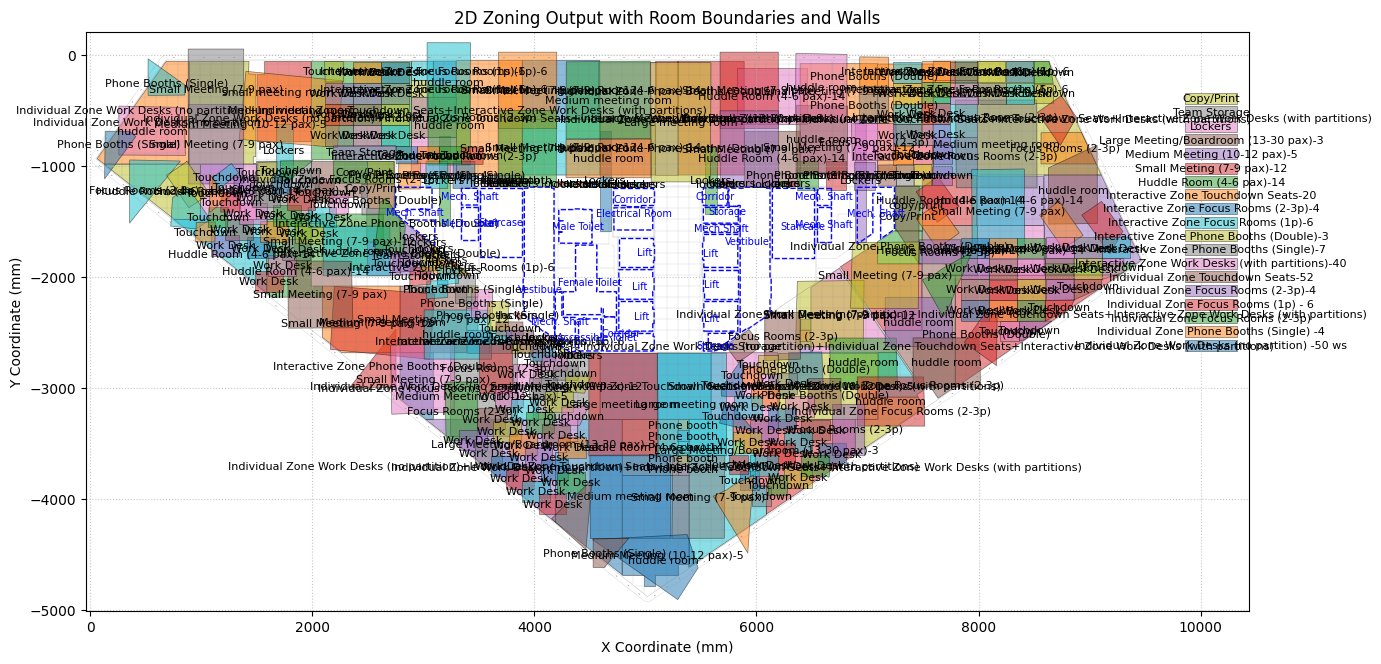

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# Get floor bounds
min_x = spatial['floor_bounds']['minX']
max_x = spatial['floor_bounds']['maxX']
min_y = spatial['floor_bounds']['minY']
max_y = spatial['floor_bounds']['maxY']

# Plot each zone polygon
for zone in zones:
    if zone['points']:
        xs = [p['x'] for p in zone['points']]
        ys = [p['y'] for p in zone['points']]
        plt.fill(xs, ys, alpha=0.5, edgecolor='black', linewidth=0.5, label=zone['spatial_name'])
        # Add text label for spatial name
        if zone['spatial_name']:
            plt.text(zone['centroid_x'], zone['centroid_y'], zone['spatial_name'], fontsize=8, ha='center', va='center', color='black')

# Plot room boundaries (as outlines)
for room in spatial['room_boundaries']:
    if room['points']:
        xs = [p['x'] for p in room['points']]
        ys = [p['y'] for p in room['points']]
        plt.plot(xs + [xs[0]], ys + [ys[0]], color='blue', linestyle='--', linewidth=1)
        # Add text label for room name
        if room['room_name']:
            plt.text(room['centroid_x'], room['centroid_y'], room['room_name'], fontsize=7, ha='center', va='center', color='blue')

# Plot walls
for wall in spatial['walls']:
    plt.plot([wall['x1'], wall['x2']], [wall['y1'], wall['y2']], color='gray', linewidth=wall['thickness']/100) # Scale thickness for visibility


plt.xlabel('X Coordinate (mm)')
plt.ylabel('Y Coordinate (mm)')
plt.title('2D Zoning Output with Room Boundaries and Walls')
plt.gca().set_aspect('equal', adjustable='box') # Maintain aspect ratio

# Set plot limits using floor bounds
plt.xlim(min_x - 100, max_x + 100)
plt.ylim(min_y - 100, max_y + 100)

plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Prepare Data for Plotly

### Subtask:
Convert the existing `zones`, `room_boundaries`, and `walls` data into a format suitable for Plotly. This will involve extracting coordinates and relevant properties for each element.


In [8]:
plotly_zones = []
plotly_room_boundaries = []
plotly_walls = []

# Process zones for Plotly
for zone in zones:
    if zone['points']:
        xs = [p['x'] for p in zone['points']]
        ys = [p['y'] for p in zone['points']]
        hover_text = (
            f"<b>Spatial Name:</b> {zone.get('spatial_name', 'N/A')}<br>" +
            f"<b>Block Name:</b> {zone.get('block_name', 'N/A')}<br>" +
            f"<b>Area (m²):</b> {zone.get('spatial_area_m2', 'N/A'):.2f}<br>" +
            f"<b>SpaceMix:</b> {zone.get('spacemix', 'N/A')}<br>" +
            f"<b>Block Type:</b> {zone.get('block_type', 'N/A')}"
        )
        plotly_zones.append({
            'xs': xs,
            'ys': ys,
            'hover_text': hover_text
        })

# Process room boundaries for Plotly
for room in spatial['room_boundaries']:
    if room['points']:
        xs = [p['x'] for p in room['points']]
        ys = [p['y'] for p in room['points']]
        plotly_room_boundaries.append({
            'xs': xs,
            'ys': ys
        })

# Process walls for Plotly
for wall in spatial['walls']:
    plotly_walls.append({
        'x1': wall['x1'],
        'y1': wall['y1'],
        'x2': wall['x2'],
        'y2': wall['y2']
    })

print(f"Prepared {len(plotly_zones)} zones, {len(plotly_room_boundaries)} room boundaries, and {len(plotly_walls)} walls for Plotly.")

Prepared 364 zones, 27 room boundaries, and 634 walls for Plotly.


## Create Interactive Plot

### Subtask:
Generate an interactive Plotly figure using the prepared `plotly_zones`, `plotly_room_boundaries`, and `plotly_walls` data. Add each element as a distinct trace to the plot, ensuring that hovering over zones displays the specified tooltip.


In [10]:
import plotly.graph_objects as go

# Create an empty Plotly figure
fig = go.Figure()

# Add zones to the figure
for zone_data in plotly_zones:
    fig.add_trace(go.Scatter(
        x=zone_data['xs'],
        y=zone_data['ys'],
        mode='lines',
        fill='toself',
        name=zone_data['hover_text'].split('<br>')[0].replace('<b>Spatial Name:</b> ', ''), # Use spatial name as trace name
        hoverinfo='text',
        hovertext=zone_data['hover_text'],
        line=dict(color='blue', width=0.5),
        fillcolor='rgba(0,0,255,0.1)',
        showlegend=False # Hide legend for individual zones
    ))

# Add room boundaries to the figure
for room_data in plotly_room_boundaries:
    fig.add_trace(go.Scatter(
        x=room_data['xs'] + [room_data['xs'][0]], # Close the loop
        y=room_data['ys'] + [room_data['ys'][0]], # Close the loop
        mode='lines',
        name='Room Boundary',
        line=dict(color='green', width=1, dash='dot'),
        hoverinfo='none',
        showlegend=False # Hide legend for individual boundaries
    ))

# Add walls to the figure
for wall_data in plotly_walls:
    # Use a default width for walls as 'thickness' was not included in plotly_walls preparation
    fig.add_trace(go.Scatter(
        x=[wall_data['x1'], wall_data['x2']],
        y=[wall_data['y1'], wall_data['y2']],
        mode='lines',
        name='Wall',
        line=dict(color='gray', width=0.1), # Default width of 0.1 (e.g., 10mm / 100)
        hoverinfo='none',
        showlegend=False # Hide legend for individual walls
    ))

print("Plotly figure created with zones, room boundaries, and walls.")

Plotly figure created with zones, room boundaries, and walls.


In [11]:
import plotly.graph_objects as go

# Configure layout
fig.update_layout(
    title_text='2D Zoning Output with Room Boundaries and Walls (Interactive)',
    xaxis_title='X Coordinate (mm)',
    yaxis_title='Y Coordinate (mm)',
    hovermode='closest',
    showlegend=False # Individual traces don't need legends
)

# Set plot limits using floor bounds from the 'spatial' dictionary
min_x = spatial['floor_bounds']['minX']
max_x = spatial['floor_bounds']['maxX']
min_y = spatial['floor_bounds']['minY']
max_y = spatial['floor_bounds']['maxY']

fig.update_xaxes(range=[min_x - 100, max_x + 100], zeroline=False)
fig.update_yaxes(range=[min_y - 100, max_y + 100], zeroline=False, scaleanchor="x", scaleratio=1)

# Display the figure
fig.show()

print("Plotly figure layout configured and displayed.")

Plotly figure layout configured and displayed.
